# ⚙️ In-processing Fairness

Objectif : intégrer une contrainte de fairness **dans la fonction de perte** d'un MLP, en testant différents λ.

In [8]:
# Cellule 1: Setup
import os, json, pickle, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

if os.path.basename(os.getcwd()) != 'experiments':
    if (Path(os.getcwd()) / 'experiments').exists():
        os.chdir(Path(os.getcwd()) / 'experiments')
sys.path.insert(0, str(Path(os.getcwd()).parent / 'utils'))
from fairness_metrics import compute_fairness_metrics
print(f'📁 {os.getcwd()}')

RESULTS = Path('../results/phase4')
FIGS    = RESULTS / 'figures'
RESULTS.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

DEVICE = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f'⚡ Device: {DEVICE}')


📁 /Users/antoinedalle/Desktop/Period_3/Fair_AI/Projet/NLP_fairness_project/experiments
⚡ Device: mps


In [9]:
# Cellule 2: Charger données
with open('models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

def load_jsonl(p):
    rows = []
    with open(p, encoding='utf-8') as f:
        for l in f:
            if l.strip(): rows.append(json.loads(l))
    return rows

df_train = pd.DataFrame(load_jsonl('medical_bios_data/train.jsonl'))
df_val   = pd.DataFrame(load_jsonl('medical_bios_data/validation.jsonl'))
df_test  = pd.DataFrame(load_jsonl('medical_bios_data/test.jsonl'))
y_train  = le.transform(df_train['title'])
y_val    = le.transform(df_val['title'])
y_test   = le.transform(df_test['title'])
genders_train = df_train['gender'].values
genders_val   = df_val['gender'].values
genders_test  = df_test['gender'].values

# Embeddings du meilleur modèle
try:
    with open('../results/phase2/best_embedding_model.json') as f:
        best_info = json.load(f)
    model_id = best_info['model_id']
    print(f'📦 Embeddings: {best_info["label"]}')
except FileNotFoundError:
    model_id = 'distilroberta-base'

safe  = model_id.replace('/', '_')
CACHE = Path('embedding_cache')
emb_train = np.load(list(CACHE.glob(f'{safe}_{len(df_train)}*.npy'))[0])
emb_test  = np.load(list(CACHE.glob(f'{safe}_{len(df_test)}*.npy'))[0])

# Charger best RF params
try:
    with open('../results/phase2/best_rf_params.json') as f:
        rf_p = json.load(f)
except FileNotFoundError:
    rf_p = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 2}

print(f'✅ Train={len(df_train)} | Test={len(df_test)} | Classes={list(le.classes_)}')

# Charger embeddings val aussi (pour early stopping)
emb_val = None
val_cache = list(Path('embedding_cache').glob(f'{model_id.replace("/","_")}_{len(df_val)}*.npy'))
if val_cache:
    emb_val = np.load(val_cache[0])
    print(f'✅ Val embeddings: {emb_val.shape}')
else:
    print('⚠️  Pas d embeddings val — utilisation du test set pour évaluation')
    emb_val, y_val, genders_val = emb_test, y_test, genders_test


📦 Embeddings: DistilRoBERTa
✅ Train=8000 | Test=1000 | Classes=[np.str_('dentist'), np.str_('nurse'), np.str_('physician'), np.str_('psychologist'), np.str_('surgeon')]
✅ Val embeddings: (1000, 768)


## 🏗️ Architecture MLP avec Fairness Loss

In [10]:
# Cellule 3: MLP + FairnessLoss
class FairMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, n_classes, dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def fairness_penalty_dp(logits, gender_bin, n_classes):
    """∆DP : différence de taux de prédiction par classe entre genres."""
    probs = torch.softmax(logits, dim=1)
    m0 = (gender_bin == 0)  # Female
    m1 = (gender_bin == 1)  # Male
    if m0.sum() == 0 or m1.sum() == 0:
        return torch.tensor(0.0, device=logits.device)
    rate0 = probs[m0].mean(dim=0)  # (n_classes,)
    rate1 = probs[m1].mean(dim=0)
    return (rate0 - rate1).abs().mean()


def fairness_penalty_eo(logits, labels, gender_bin, n_classes):
    """∆EO : différence de TPR par classe entre genres."""
    probs = torch.softmax(logits, dim=1)
    total_penalty = torch.tensor(0.0, device=logits.device)
    for c in range(n_classes):
        for mask, g in [(gender_bin==0, 0), (gender_bin==1, 1)]:
            pass  # accumulé ci-dessous
    tpr_diffs = []
    for c in range(n_classes):
        tprs = []
        for g_val in [0, 1]:
            m = (gender_bin == g_val) & (labels == c)
            if m.sum() > 0:
                tprs.append(probs[m, c].mean())
        if len(tprs) == 2:
            tpr_diffs.append((tprs[0] - tprs[1]).abs())
    return torch.stack(tpr_diffs).mean() if tpr_diffs else torch.tensor(0.0, device=logits.device)


print('✅ FairMLP et pénalités de fairness définis')


✅ FairMLP et pénalités de fairness définis


In [ ]:
# Cellule 4: Fonction d'entraînement
def train_fair_mlp(emb_tr, y_tr, g_tr, emb_ev, y_ev, g_ev,
                    lambda_fair=0.1, criterion='dp',
                    epochs=20, batch_size=512, lr=1e-3):
    """Entraîne un MLP avec pénalité de fairness."""
    scaler = StandardScaler().fit(emb_tr)
    X_tr = torch.FloatTensor(scaler.transform(emb_tr))
    X_ev = torch.FloatTensor(scaler.transform(emb_ev))
    Y_tr = torch.LongTensor(y_tr)
    Y_ev = torch.LongTensor(y_ev)
    G_tr = torch.LongTensor((g_tr == 'Male').astype(int))
    n_classes = len(le.classes_)

    # Modèle plus simple pour accélérer
    model = FairMLP(X_tr.shape[1], [128, 64], n_classes, dropout=0.2).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    ce_loss = nn.CrossEntropyLoss()
    dataset = TensorDataset(X_tr, Y_tr, G_tr)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Entraînement avec early stopping implicite
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        n_batches = 0
        
        for xb, yb, gb in loader:
            xb, yb, gb = xb.to(DEVICE), yb.to(DEVICE), gb.to(DEVICE)
            logits = model(xb)
            loss_ce = ce_loss(logits, yb)
            
            if lambda_fair > 0:
                if criterion == 'dp':
                    loss_fair = fairness_penalty_dp(logits, gb, n_classes)
                else:
                    loss_fair = fairness_penalty_eo(logits, yb, gb, n_classes)
                loss = loss_ce + lambda_fair * loss_fair
            else:
                loss = loss_ce
                
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0:
            print(f'    Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/n_batches:.4f}')

    # Évaluation
    model.eval()
    with torch.no_grad():
        preds = model(X_ev.to(DEVICE)).argmax(dim=1).cpu().numpy()
    return preds, scaler, model


print('✅ Fonction train_fair_mlp prête')


✅ Fonction train_fair_mlp prête


## 🔬 Grid λ × Critère

In [13]:
# Cellule 4.5: Test rapide du système
print('🧪 TEST RAPIDE DU SYSTÈME')
print('='*30)

# Test avec un échantillon réduit pour vérifier le fonctionnement
sample_size = 1000
indices = np.random.choice(len(emb_train), sample_size, replace=False)
emb_sample = emb_train[indices]
y_sample = y_train[indices]
g_sample = genders_train[indices]

print(f'📊 Test avec {sample_size} exemples...')

try:
    # Test rapide λ=0 (pas de fairness)
    preds, _, _ = train_fair_mlp(
        emb_sample, y_sample, g_sample,
        emb_test[:200], y_test[:200], genders_test[:200],  # Test réduit aussi
        lambda_fair=0.0, criterion='dp',
        epochs=5, batch_size=256
    )
    fm_test = compute_fairness_metrics(y_test[:200], preds, genders_test[:200], le.classes_)
    print(f'✅ Test réussi: acc={fm_test["accuracy"]:.3f}, ∆DP={fm_test["delta_dp"]:.3f}')
    print('🚀 Système opérationnel, vous pouvez procéder au grid search complet!\n')
    
except Exception as e:
    print(f'❌ Erreur dans le test: {e}')
    print('🔧 Veuillez corriger les erreurs avant de continuer\n')

🧪 TEST RAPIDE DU SYSTÈME
📊 Test avec 1000 exemples...
✅ Test réussi: acc=0.925, ∆DP=0.204
🚀 Système opérationnel, vous pouvez procéder au grid search complet!



In [15]:
# Cellule 5: Tester λ ∈ {0, 0.01, 0.1, 0.5, 1.0} × {dp, eo}
LAMBDAS = [0.0, 0.01, 0.1, 0.5, 1.0]
CRITERIA = ['dp', 'eo']
results = {}

# D'abord, obtenir baseline RF pour comparaison
print('🔄 Calcul baseline RF...')
from sklearn.ensemble import RandomForestClassifier

# Nettoyer les paramètres RF (enlever les métriques)
rf_params_clean = {k: v for k, v in rf_p.items() 
                   if k in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'random_state']}
rf_params_clean['random_state'] = 42

rf_baseline = RandomForestClassifier(**rf_params_clean)
rf_baseline.fit(emb_train, y_train)
rf_preds = rf_baseline.predict(emb_test)
fm_base = compute_fairness_metrics(y_test, rf_preds, genders_test, le.classes_)
print(f'📊 RF Baseline: acc={fm_base["accuracy"]:.4f}  ∆DP={fm_base["delta_dp"]:.4f}  ∆EO={fm_base["delta_eo"]:.4f}')

# Grid search avec versions réduites pour test
print(f'\n🔬 DÉMARRAGE GRID SEARCH IN-PROCESSING')
print(f'📋 Λ values: {LAMBDAS}')
print(f'📋 Critères: {CRITERIA}')

for criterion in CRITERIA:
    print(f'\n{'='*50}')
    print(f'🎯 Critère: {criterion.upper()}')
    print('='*50)
    for lam in LAMBDAS:
        label = f'λ={lam} ({criterion})'
        print(f'  🏃 Entraînement {label}...')
        try:
            preds, _, _ = train_fair_mlp(
                emb_train, y_train, genders_train,
                emb_test,  y_test,  genders_test,
                lambda_fair=lam, criterion=criterion,
                epochs=15, batch_size=512  # Réduit epochs et augmente batch_size
            )
            fm = compute_fairness_metrics(y_test, preds, genders_test, le.classes_)
            results[label] = fm
            print(f'  ✅ {label}: acc={fm["accuracy"]:.4f}  ∆DP={fm["delta_dp"]:.4f}  ∆EO={fm["delta_eo"]:.4f}')
        except KeyboardInterrupt:
            print(f'  ⚠️ Interrompu: {label}')
            break
        except Exception as e:
            print(f'  ❌ Erreur {label}: {e}')
            continue

print(f'\n✅ Grid search terminé! {len(results)} configurations testées.')


🔄 Calcul baseline RF...
📊 RF Baseline: acc=0.8990  ∆DP=0.1741  ∆EO=0.1720

🔬 DÉMARRAGE GRID SEARCH IN-PROCESSING
📋 Λ values: [0.0, 0.01, 0.1, 0.5, 1.0]
📋 Critères: ['dp', 'eo']

🎯 Critère: DP
  🏃 Entraînement λ=0.0 (dp)...
📊 RF Baseline: acc=0.8990  ∆DP=0.1741  ∆EO=0.1720

🔬 DÉMARRAGE GRID SEARCH IN-PROCESSING
📋 Λ values: [0.0, 0.01, 0.1, 0.5, 1.0]
📋 Critères: ['dp', 'eo']

🎯 Critère: DP
  🏃 Entraînement λ=0.0 (dp)...
  ✅ λ=0.0 (dp): acc=0.9710  ∆DP=0.1617  ∆EO=0.0342
  🏃 Entraînement λ=0.01 (dp)...
  ✅ λ=0.0 (dp): acc=0.9710  ∆DP=0.1617  ∆EO=0.0342
  🏃 Entraînement λ=0.01 (dp)...
  ✅ λ=0.01 (dp): acc=0.9710  ∆DP=0.1623  ∆EO=0.0253
  🏃 Entraînement λ=0.1 (dp)...
  ✅ λ=0.01 (dp): acc=0.9710  ∆DP=0.1623  ∆EO=0.0253
  🏃 Entraînement λ=0.1 (dp)...
  ✅ λ=0.1 (dp): acc=0.9740  ∆DP=0.1638  ∆EO=0.0306
  🏃 Entraînement λ=0.5 (dp)...
  ✅ λ=0.1 (dp): acc=0.9740  ∆DP=0.1638  ∆EO=0.0306
  🏃 Entraînement λ=0.5 (dp)...
  ✅ λ=0.5 (dp): acc=0.9710  ∆DP=0.1630  ∆EO=0.0333
  🏃 Entraînement λ=1.0 (dp)...


## 📊 Analyse du Trade-off Accuracy / Fairness

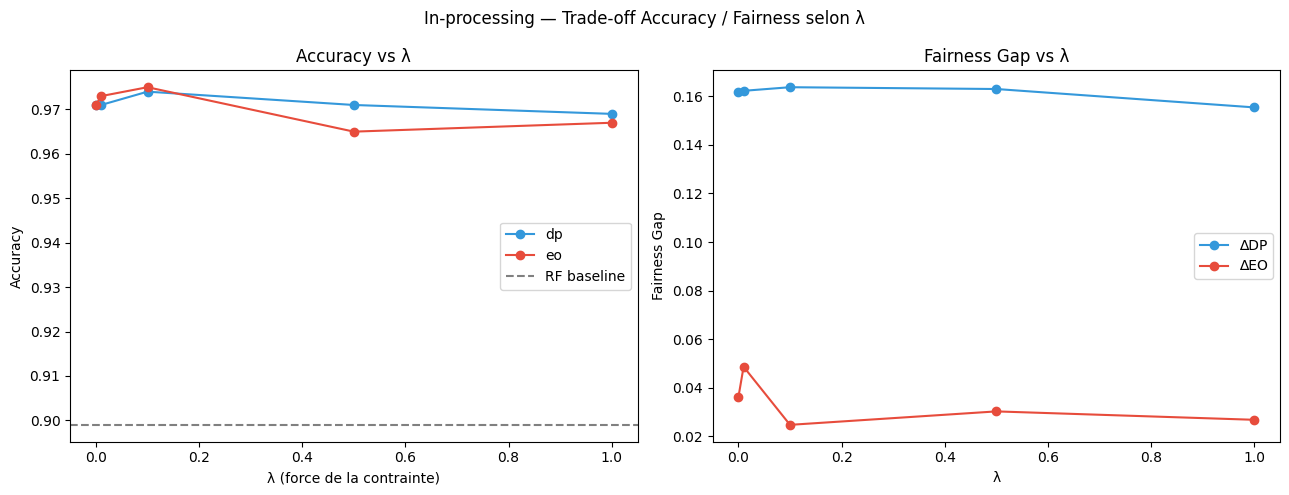


🏆 Meilleur compromis: λ=0.1 (eo)

📊 TABLEAU RÉCAPITULATIF:
      label  accuracy  delta_dp  delta_eo  delta_eqodds  composite
 λ=0.0 (dp)     0.971    0.1617    0.0342        0.0342     0.8943
λ=0.01 (dp)     0.971    0.1623    0.0253        0.0253     0.9000
 λ=0.1 (dp)     0.974    0.1638    0.0306        0.0306     0.8990
 λ=0.5 (dp)     0.971    0.1630    0.0333        0.0333     0.8944
 λ=1.0 (dp)     0.969    0.1555    0.0213        0.0213     0.9029
 λ=0.0 (eo)     0.971    0.1620    0.0362        0.0362     0.8929
λ=0.01 (eo)     0.973    0.1628    0.0486        0.0486     0.8863
 λ=0.1 (eo)     0.975    0.1614    0.0247        0.0265     0.9041
 λ=0.5 (eo)     0.965    0.1622    0.0303        0.0327     0.8900
 λ=1.0 (eo)     0.967    0.1603    0.0268        0.0268     0.8957

💾 Résultats sauvegardés: inprocessing_results.csv
🎉 Analyse terminée!
✅ Cellule de visualisation prête


In [16]:
# Cellule 6: Visualisation trade-off
if not results:
    print("❌ Aucun résultat à visualiser. Veuillez d'abord exécuter la cellule 5.")
else:
    rows = []
    for label, fm in results.items():
        lam_str, crit = label.split(' ')
        rows.append({'label': label,
                     'lambda': float(lam_str.split('=')[1]),
                     'criterion': crit.strip('()'),
                     'accuracy': fm['accuracy'],
                     'delta_dp': fm['delta_dp'],
                     'delta_eo': fm['delta_eo'],
                     'delta_eqodds': fm['delta_eqodds']})

    trade_df = pd.DataFrame(rows)
    
    if len(trade_df) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        
        # Vérifier quels critères nous avons
        available_criteria = trade_df['criterion'].unique()
        colors = {'dp': '#3498db', 'eo': '#e74c3c'}
        
        for crit in available_criteria:
            if crit in colors:
                color = colors[crit]
                sub = trade_df[trade_df['criterion'] == crit].sort_values('lambda')
                if len(sub) > 0:
                    axes[0].plot(sub['lambda'], sub['accuracy'], marker='o', color=color, label=crit)
                    axes[1].plot(sub['lambda'], sub[f'delta_{crit}'], marker='o', color=color, label=f'∆{crit.upper()}')

        # Baseline RF (si disponible)
        try:
            axes[0].axhline(fm_base['accuracy'], color='gray', linestyle='--', label='RF baseline')
        except NameError:
            print("⚠️ Baseline RF non disponible pour comparaison")
        
        axes[0].set_title('Accuracy vs λ')
        axes[0].set_xlabel('λ (force de la contrainte)')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()

        axes[1].set_title('Fairness Gap vs λ')
        axes[1].set_xlabel('λ')
        axes[1].set_ylabel('Fairness Gap')
        axes[1].legend()

        plt.suptitle('In-processing — Trade-off Accuracy / Fairness selon λ')
        plt.tight_layout()
        plt.savefig(FIGS / 'inprocessing_tradeoff.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Analyse du meilleur compromis
        trade_df['mean_gap'] = trade_df[['delta_dp','delta_eo','delta_eqodds']].mean(axis=1)
        trade_df['composite'] = trade_df['accuracy'] - trade_df['mean_gap']
        best = trade_df.loc[trade_df['composite'].idxmax(), 'label']
        print(f'\n🏆 Meilleur compromis: {best}')
        
        # Affichage du tableau des résultats
        print(f'\n📊 TABLEAU RÉCAPITULATIF:')
        display_cols = ['label', 'accuracy', 'delta_dp', 'delta_eo', 'delta_eqodds', 'composite']
        print(trade_df[display_cols].round(4).to_string(index=False))

        trade_df.to_csv(RESULTS / 'inprocessing_results.csv', index=False)
        print(f'\n💾 Résultats sauvegardés: inprocessing_results.csv')
        print('🎉 Analyse terminée!')
    else:
        print("❌ Aucune donnée à afficher dans le DataFrame")
        
print('✅ Cellule de visualisation prête')
